In [42]:
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [43]:
data = loadmat(r"C:\WINDLAB_SUMMER\TPU_TEST_FILES\WIND_HIGH_RISE\T213_4_015_1.mat")


# 1. Flip the location data so it's a table
loc_matrix = data['Location_of_measured_points']
loc_df = pd.DataFrame(loc_matrix.T, columns=['X', 'Y', 'Point_No', 'Face_No'])

# 2. Extract the pressure time-series
if 'Wind_pressure_coefficients' in data:
    pressure_df = pd.DataFrame(data['Wind_pressure_coefficients'])
elif 'Pressure_coefficients' in data:
    pressure_df = pd.DataFrame(data['Pressure_coefficients'])
else:
    raise KeyError("Could not find any pressure coefficient matrices in this file!")
print(f"Total Taps: {len(loc_df)}")
print(f"Total Timesteps: {len(pressure_df)}")

#print(loc_df.iloc[41])

Total Taps: 360
Total Timesteps: 32768


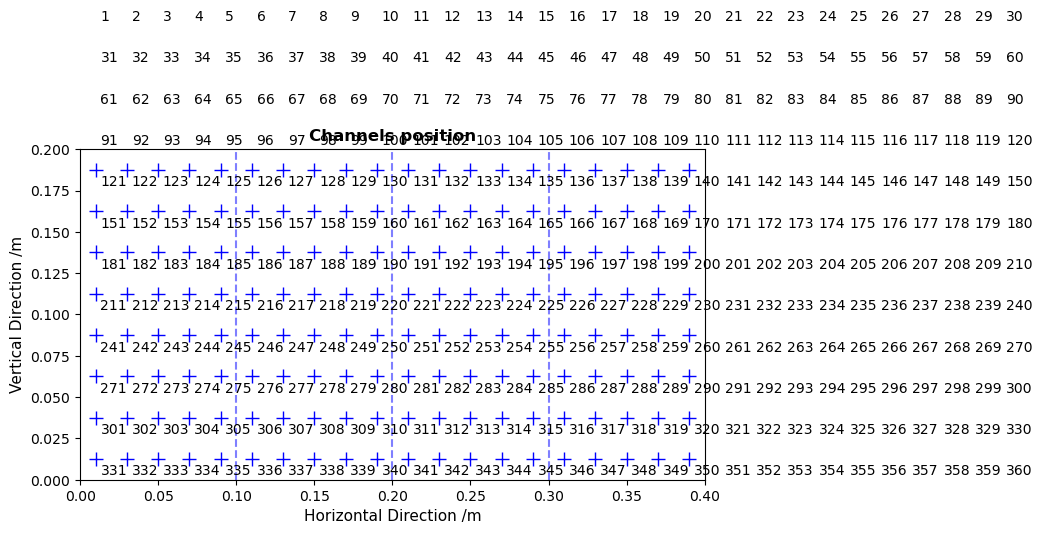

In [44]:
plt.figure(figsize=(12, 6))

# 2. Plot the taps as blue crosses
plt.scatter(loc_df['X'], loc_df['Y'], marker='+', color='blue', s=100, linewidth=1)

# 3. Iterate through the dataframe to label each tap with its 'Point_No'
for index, row in loc_df.iterrows():
    point_num = int(row['Point_No'])
    x_val = row['X']
    y_val = row['Y']
    
    # Offset the text slightly down and to the right so it doesn't overlap the cross
    plt.text(x_val + 0.003, y_val - 0.003, str(point_num), 
             color='black', fontsize=10, ha='left', va='top')

# 4. Add the vertical dashed lines separating the faces/sections (at X = 0.1, 0.2, 0.3)
for v_line in [0.1, 0.2, 0.3]:
    plt.axvline(x=v_line, color='blue', linestyle='--', alpha=0.5)

# 5. Lock the axes limits to perfectly match the original MATLAB plot
plt.xlim(0, 0.4)
plt.ylim(0, 0.2)

# 6. Add the exact titles and axis labels
plt.title("Channels position", fontweight='bold', fontsize=12)
plt.xlabel("Horizontal Direction /m", fontsize=11)
plt.ylabel("Vertical Direction /m", fontsize=11)

# Show the fully reconstructed plot
plt.tight_layout()
plt.show()

In [45]:
print(pressure_df.T.head(15))

       0         1         2         3         4         5         6      \
0   0.098187  0.107670  0.139924  0.149945  0.176932  0.287174  0.290523   
1   0.265668  0.263159  0.282661  0.243521  0.292381  0.428472  0.437709   
2   0.307313  0.286205  0.267951  0.260266  0.316660  0.407954  0.365578   
3   0.334648  0.234628  0.208829  0.158763  0.188358  0.313444  0.300819   
4   0.217301  0.156932  0.176825  0.154267  0.168041  0.277982  0.257934   
5   0.219128  0.134058  0.148139  0.126906  0.152265  0.265049  0.260078   
6   0.243547  0.145626  0.165215  0.152375  0.213538  0.344995  0.319972   
7   0.446212  0.327120  0.325672  0.251105  0.271630  0.410127  0.435974   
8   0.450970  0.321898  0.361304  0.264029  0.317939  0.432739  0.488113   
9   0.437071  0.371831  0.396321  0.359774  0.396097  0.451945  0.460513   
10 -1.062172 -0.890939 -0.971652 -0.907696 -0.941432 -0.903925 -0.946620   
11 -0.831772 -0.669497 -0.812437 -0.800496 -0.834895 -0.969620 -1.025451   
12 -0.576541

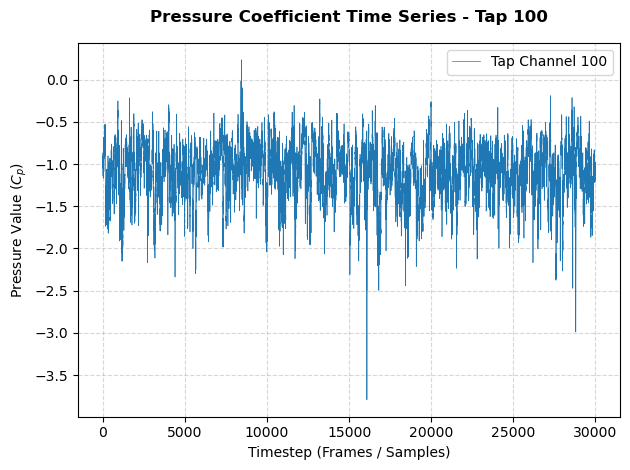

In [46]:
def get_timeseries_plot(pressure_df, tap_no, time_a, time_b):
    tap_idx = int(tap_no)
    start_idx = int(time_a)
    end_idx = int(time_b)


    pressure_tap_no = pressure_df[tap_idx]

    sliced_pressure = pressure_tap_no.iloc[start_idx: end_idx]

    plt.plot(
        sliced_pressure.index, 
        sliced_pressure.values, 
        color='#1f77b4', 
        linewidth=0.5, 
        label=f'Tap Channel {tap_no}'
    )

    plt.title(f'Pressure Coefficient Time Series - Tap {tap_no}', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Timestep (Frames / Samples)', fontsize=10)
    plt.ylabel('Pressure Value ($C_p$)', fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()

    plt.show()

get_timeseries_plot(pressure_df, 100, 1, 30000)

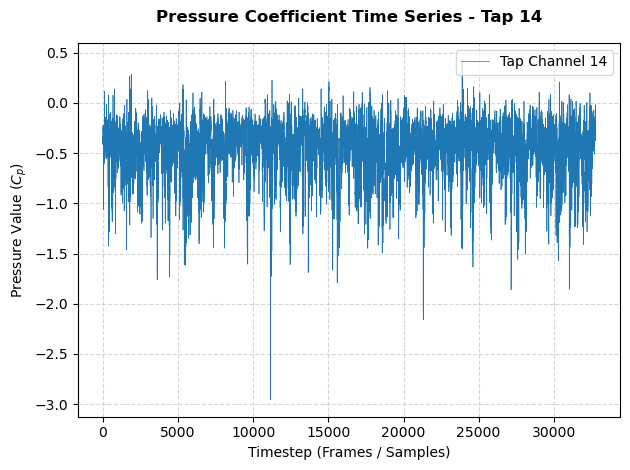

In [47]:
def view_all_steps(pressure_df, tap_no):
    tap_idx = int(tap_no)

    pressure_at_tap = pressure_df[tap_idx]


    plt.plot(
        pressure_at_tap.index, 
        pressure_at_tap.values, 
        color='#1f77b4', 
        linewidth=0.5, 
        label=f'Tap Channel {tap_no}'
    )

    
    plt.title(f'Pressure Coefficient Time Series - Tap {tap_no}', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Timestep (Frames / Samples)', fontsize=10)
    plt.ylabel('Pressure Value ($C_p$)', fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()

    plt.show()

view_all_steps(pressure_df, 14)



In [48]:
min_val = pressure_df[14].idxmin()
print(min_val)

11144


In [49]:
mean_cp_series = pressure_df.mean(axis = 0)
mean_cp_df = mean_cp_series.reset_index()
mean_cp_df.columns = ['Tap no.', 'mean_cp']

print(mean_cp_df)

     Tap no.   mean_cp
0          0  0.229367
1          1  0.397794
2          2  0.444317
3          3  0.472097
4          4  0.492563
..       ...       ...
355      355 -0.709777
356      356 -0.679003
357      357 -0.692299
358      358 -0.690126
359      359 -0.669801

[360 rows x 2 columns]


In [50]:
all_means = mean_cp_df['mean_cp'].values
num_taps = len(loc_df)
matched_means = all_means[:num_taps]

# 4. Paste it directly into the coordinate DataFrame
loc_df['mean_cp'] = matched_means

print(f"Successfully mapped {len(matched_means)} mean Cp values to the coordinates.")
#print(mean_cp_df)
print(loc_df)


Successfully mapped 360 mean Cp values to the coordinates.
        X       Y  Point_No  Face_No   mean_cp
0    0.01  0.2875       1.0      1.0  0.229367
1    0.03  0.2875       2.0      1.0  0.397794
2    0.05  0.2875       3.0      1.0  0.444317
3    0.07  0.2875       4.0      1.0  0.472097
4    0.09  0.2875       5.0      1.0  0.492563
..    ...     ...       ...      ...       ...
355  0.51  0.0125     356.0      4.0 -0.709777
356  0.53  0.0125     357.0      4.0 -0.679003
357  0.55  0.0125     358.0      4.0 -0.692299
358  0.57  0.0125     359.0      4.0 -0.690126
359  0.59  0.0125     360.0      4.0 -0.669801

[360 rows x 5 columns]


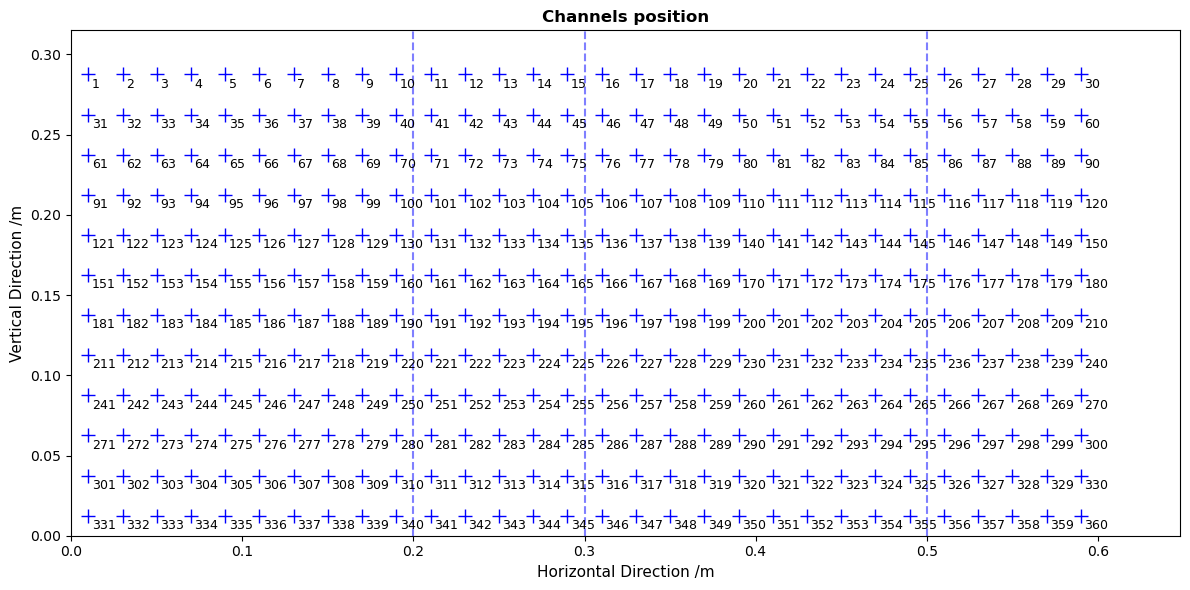

In [51]:
def get_channel_plot(loc_df, pressure_df):
        plt.figure(figsize=(12, 6))

        # 2. MATCH SIZES: Cap the location coordinates to the exact number of active channels
        total_active_channels = pressure_df.shape[1] # Number of columns in pressure matrix (200)
        active_loc_df = loc_df.head(total_active_channels).copy()

        # 3. Double-check column mapping if things look upside down:
        # If X and Y are swapped in the source matrix, flip them here:
        # x_coords = active_loc_df['Y'] 
        # y_coords = active_loc_df['X']
        x_coords = active_loc_df['X']
        y_coords = active_loc_df['Y']

        # Plot the active taps as blue crosses
        plt.scatter(x_coords, y_coords, marker='+', color='blue', s=100, linewidth=1)

        # 4. Iterate ONLY through the active capped dataframe
        for index, row in active_loc_df.iterrows():
            point_num = int(row['Point_No'])
            x_val = row['X']
            y_val = row['Y']
            
            # Offset the text slightly down and to the right so it doesn't overlap
            plt.text(x_val + 0.002, y_val - 0.002, str(point_num), 
                     color='black', fontsize=9, ha='left', va='top')

        # Add the vertical dashed lines separating sections

        # 1. Sort the taps horizontally from left to right
        sorted_loc = active_loc_df.sort_values(by='X')

        # 2. Track where the Face Number changes from one row to the next
        face_changes = sorted_loc['Face_No'].ne(sorted_loc['Face_No'].shift())
        
        # 3. Extract the exact X-coordinates where those shifts happen
        # We skip the very first point (index 0) because that's just the outer left wall
        boundary_xs = sorted_loc[face_changes]['X'].values[1:]

        # 4. Draw the dashed boundary lines exactly at the structural seam transitions
        for v_line in boundary_xs:

            snapped_line = round(v_line, 1)

            plt.axvline(x=snapped_line, color='blue', linestyle='--', alpha=0.5)

        # Lock the axes limits perfectly to the original geometry bounds
        x_min, x_max = x_coords.min(), x_coords.max()
        y_min, y_max = y_coords.min(), y_coords.max()
        
        x_buffer = (x_max - x_min) * 0.1 if x_max != x_min else 0.05
        y_buffer = (y_max - y_min) * 0.1 if y_max != y_min else 0.05

        plt.xlim(max(0, x_min - x_buffer), x_max + x_buffer)
        plt.ylim(max(0, y_min - y_buffer), y_max + y_buffer)

        plt.title("Channels position", fontweight='bold', fontsize=12)
        plt.xlabel("Horizontal Direction /m", fontsize=11)
        plt.ylabel("Vertical Direction /m", fontsize=11)

        plt.tight_layout()
        plt.show()

get_channel_plot(loc_df, pressure_df)

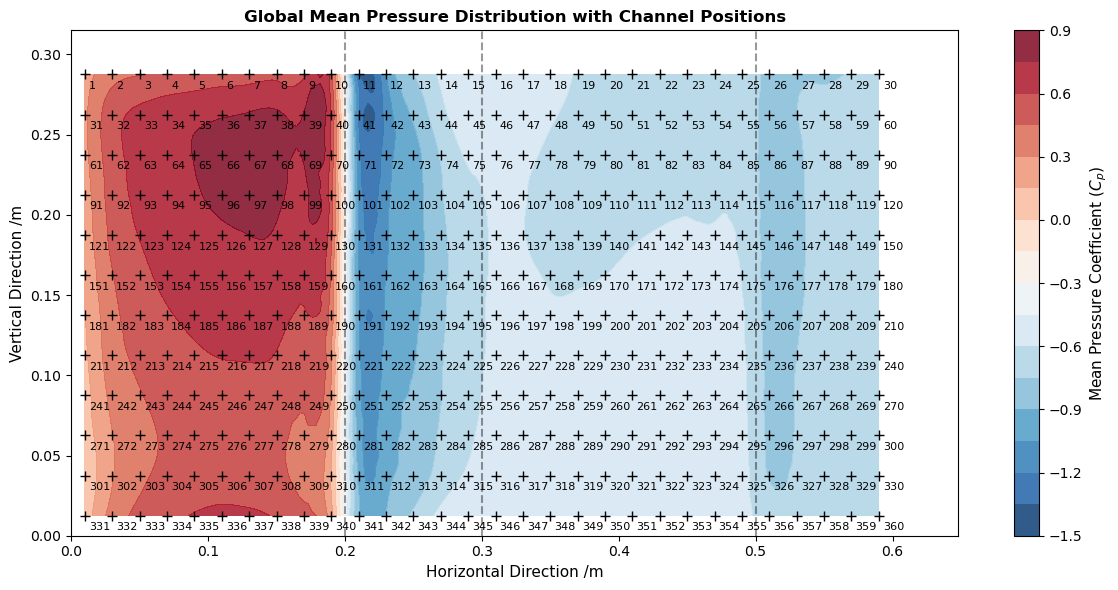

In [52]:
def mean_cp_contour(pressure_df, loc_df):
    # 1. Calculate the mean pressure coefficient (Cp) for every single channel
    mean_cp_series = pressure_df.mean(axis=0)
    mean_cp_df = mean_cp_series.reset_index()
    mean_cp_df.columns = ['Tap no.', 'mean_cp']

    all_means = mean_cp_df['mean_cp'].values
    num_taps = len(loc_df)
    matched_means = all_means[:num_taps]

    # Paste the calculated means directly into a copy of the coordinate DataFrame
    working_loc_df = loc_df.copy()
    working_loc_df['mean_cp'] = matched_means

    # =====================================================================
    # 🟢 OPTION B INTEGRATION: DROP SPATIAL DUPLICATES TO PREVENT QHULL ERRORS
    # =====================================================================
    clean_df = working_loc_df.drop_duplicates(subset=['X', 'Y'])
    
    x = clean_df['X'].values
    y = clean_df['Y'].values
    z = clean_df['mean_cp'].values

    # =====================================================================
    # 🔵 DYNAMIC GRID GENERATION (Scales automatically to any dataset size)
    # =====================================================================
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()

    # Create a dense grid mesh based on the absolute dimensions of the active data
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 100)
    )

    # Interpolate the scattered pressure points onto the dense coordinate grid mesh
    grid_z = griddata((x, y), z, (grid_x, grid_y), method='cubic')

    # =====================================================================
    # 🎨 PLOTTING AND VISUALIZATION
    # =====================================================================
    plt.figure(figsize=(12, 6))

    # Plot the smooth color contour bands (RdBu_r = Classic Aerodynamic Red/Blue map)
    contour = plt.contourf(grid_x, grid_y, grid_z, levels=20, cmap='RdBu_r', alpha=0.85)

    # Add the colorbar legend to the right side
    cbar = plt.colorbar(contour)
    cbar.set_label('Mean Pressure Coefficient ($C_p$)', fontsize=11)

    # Overlay the original tap locations as black crosses for visibility contrast
    plt.scatter(x, y, marker='+', color='black', s=60, linewidth=1)

    # Overlay the tap text labels
    for index, row in clean_df.iterrows():
        # Dynamic label offsets based on graph size metrics
        x_offset = (x_max - x_min) * 0.005
        y_offset = (y_max - y_min) * 0.015
        
        plt.text(row['X'] + x_offset, row['Y'] - y_offset, str(int(row['Point_No'])), 
                    color='black', fontsize=8, ha='left', va='top')

    # Dynamic Face Boundaries: Detect transitions and round to nearest decimal place
    sorted_loc = clean_df.sort_values(by='X')
    face_changes = sorted_loc['Face_No'].ne(sorted_loc['Face_No'].shift())
    boundary_xs = sorted_loc[face_changes]['X'].values[1:]

    for v_line in boundary_xs:
        snapped_line = round(v_line, 1)
        plt.axvline(x=snapped_line, color='black', linestyle='--', alpha=0.4)

    # Add Dynamic Bounding Box Margins (10% padding cushion)
    x_buffer = (x_max - x_min) * 0.1 if x_max != x_min else 0.05
    y_buffer = (y_max - y_min) * 0.1 if y_max != y_min else 0.05

    plt.xlim(max(0, x_min - x_buffer), x_max + x_buffer)
    plt.ylim(max(0, y_min - y_buffer), y_max + y_buffer)

    # Labels & Presentation
    plt.title("Global Mean Pressure Distribution with Channel Positions", fontweight='bold', fontsize=12)
    plt.xlabel("Horizontal Direction /m", fontsize=11)
    plt.ylabel("Vertical Direction /m", fontsize=11)

    plt.tight_layout()
    plt.show()

mean_cp_contour(pressure_df, loc_df)



In [82]:
no_eave = loadmat(r"C:\WINDLAB_SUMMER\TPU_TEST_FILES\WIND_LOW_RISE_WITH_EAVE\Cp_ts_ROH12_deg000.mat")

# 1. Flip the location data so it's a table
loc_matrix = no_eave['Location_of_measured_points']
loc_df = pd.DataFrame(loc_matrix.T, columns=['X', 'Y', 'Point_No', 'Face_No'])

# 2. Extract the pressure time-series
pressure_df = pd.DataFrame(no_eave['Wind_pressure_coefficients'])

print(f"Total Taps: {len(loc_df)}")
print(f"Total Timesteps: {len(pressure_df)}")

print(loc_df.iloc[41])


Total Taps: 208
Total Timesteps: 14063
X           -1.0
Y            1.0
Point_No    42.0
Face_No      1.0
Name: 41, dtype: float32


Successfully sync'd dataset: 192 active channels found.


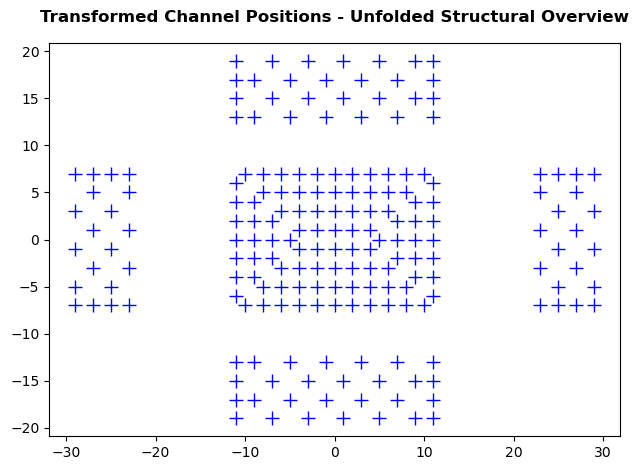

In [96]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.io import loadmat

def generate_unfolded_building_plot(mat_path):
    # =====================================================================
    # 1. LOAD AND PARSE MATLAB MATRIX FILE
    # =====================================================================
    if not os.path.exists(mat_path):
        raise FileNotFoundError(f"Could not locate target file at: {mat_path}")
        
    mat_data = loadmat(mat_path)
    
    # Extract structural location tracker matrix
    raw_loc = mat_data['Location_of_measured_points']
    
    # Convert 4xN matrix to a clean row-by-column Pandas DataFrame
    loc_df = pd.DataFrame(raw_loc.T, columns=['X', 'Y', 'Point_No', 'Face_No'])
    
    # Route matching for the pressure data keys to find the active channel count
    pressure_key = 'Wind_pressure_coefficients' if 'Wind_pressure_coefficients' in mat_data else 'Pressure_coefficients'
    if pressure_key in mat_data:
        total_active_taps = mat_data[pressure_key].shape[1] # Columns = Taps count
        loc_df = loc_df.head(total_active_taps).copy()
        print(f"Successfully sync'd dataset: {total_active_taps} active channels found.")
    else:
        print("⚠️ Warning: No pressure matrix found. Plotting global coordinates list.")


    x = loc_df['X']
    y = loc_df ['Y']

    plt.scatter(x,y, marker='+', color='blue', s=100, linewidth=1)
        
    # 🟢 Create a dictionary of DataFrames for faces 1 through 8
    face_dfs = {face: loc_df[loc_df['Face_No'] == face].reset_index(drop=True) for face in range(1, 9)}


  
    plt.title("Transformed Channel Positions - Unfolded Structural Overview", fontweight='bold', fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

# =====================================================================
# EXECUTION TRIGGER EXAMPLE
# =====================================================================
# Change this path string to point to your local file location to run!
file_target = "C:\WINDLAB_SUMMER\TPU_TEST_FILES\WIND_LOW_RISE_NO_EAVE\Cp_ts_h12042700.mat"
generate_unfolded_building_plot(file_target)

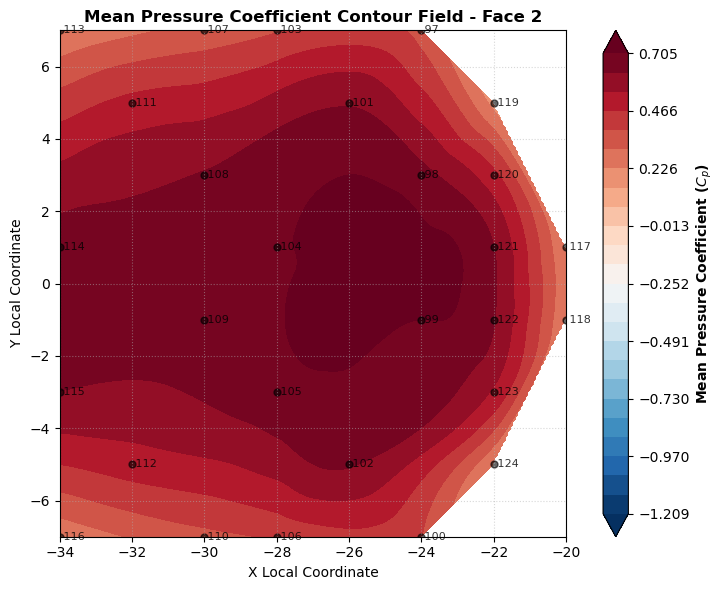

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def plot_single_face_contour(loc_df, pressure_df, face_id):
    """
    Generates a dedicated mean Cp contour plot for one explicitly chosen building face.
    
    Parameters:
    - loc_df: DataFrame containing the raw tap coordinates ('X', 'Y', 'Point_No', 'Face_No')
    - pressure_df: DataFrame containing the time-series wind pressure coefficients
    - face_id: Integer (e.g., 1, 2, 5) targeting the specific face to visualize
    """
    # 1. Calculate the mean pressure coefficient (Cp) for each channel
    mean_cp_series = pressure_df.mean(axis=0)
    mean_cp_df = mean_cp_series.reset_index()
    mean_cp_df.columns = ['Tap no.', 'mean_cp']

    # 2. Map the means back to the coordinates
    total_active_channels = pressure_df.shape[1]
    working_df = loc_df.head(total_active_channels).copy()
    working_df['mean_cp'] = mean_cp_df['mean_cp'].values[:total_active_channels]

    # Get the global min and max Cp across the entire building to keep color scales consistent
    vmin = working_df['mean_cp'].min()
    vmax = working_df['mean_cp'].max()
    levels = np.linspace(vmin, vmax, 25)

    # 3. Isolate the data specifically for the requested face
    face_data = working_df[working_df['Face_No'] == face_id].copy()
    
    if face_data.empty:
        print(f"❌ Error: Face {face_id} was not found in this dataset or contains no active data channels.")
        return

    # Remove any duplicate tap positions within this face zone
    face_data = face_data.drop_duplicates(subset=['X', 'Y'])
    
    # We need at least 3 unique tap coordinates to calculate a 2D surface field mesh
    if len(face_data) < 3:
        print(f"⚠️ Face {face_id} has only {len(face_data)} unique points. Switching to 'nearest' mapping grid fallback.")
        method_choice = 'nearest'
    else:
        method_choice = 'cubic'

    x = face_data['X'].values
    y = face_data['Y'].values
    z = face_data['mean_cp'].values

    # 4. Handle Flat 1D Profiles (e.g., if a wall face only has one straight row of sensors)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    
    # Nudge the mesh limits if coordinates are perfectly aligned to prevent QhullError crashes
    if x_min == x_max:
        x_min -= 0.01
        x_max += 0.01
        method_choice = 'nearest'  # Force nearest neighbor if geometrically flat
    if y_min == y_max:
        y_min -= 0.01
        y_max += 0.01
        method_choice = 'nearest'

    # 5. Create a dense coordinate mesh grid for this isolated face
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # 6. Interpolate values locally onto the mesh grid
    try:
        grid_z = griddata((x, y), z, (grid_x, grid_y), method=method_choice)
    except Exception:
        # Emergency absolute backup if triangulation matrices break down
        grid_z = griddata((x, y), z, (grid_x, grid_y), method='nearest')

    # =====================================================================
    # 🎨 RENDER THE TARGET FACE CHART
    # =====================================================================
    plt.figure(figsize=(8, 6))
    
    # Plot the color filled contours
    contour = plt.contourf(grid_x, grid_y, grid_z, levels=levels, cmap='RdBu_r', extend='both')
    
    # Add the colorbar scale (sharing the uniform building bounds)
    cbar = plt.colorbar(contour)
    cbar.set_label('Mean Pressure Coefficient ($C_p$)', fontweight='bold')
    
    # Overlay the exact tap locations as crisp black dots
    plt.scatter(x, y, color='black', s=25, marker='o', alpha=0.6, label='Pressure Taps')
    
    # Add tap labels (Point Number indices)
    for _, row in face_data.iterrows():
        plt.text(row['X'], row['Y'], f" {int(row['Point_No'])}", 
                 color='black', fontsize=8, alpha=0.8, ha='left', va='center')

    # Formatting presentation layers
    plt.title(f"Mean Pressure Coefficient Contour Field - Face {face_id}", fontweight='bold', fontsize=12)
    plt.xlabel("X Local Coordinate", fontsize=10)
    plt.ylabel("Y Local Coordinate", fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.show()

plot_single_face_contour(loc_df, pressure_df, 2)

Successfully sync'd dataset: 208 active channels found.


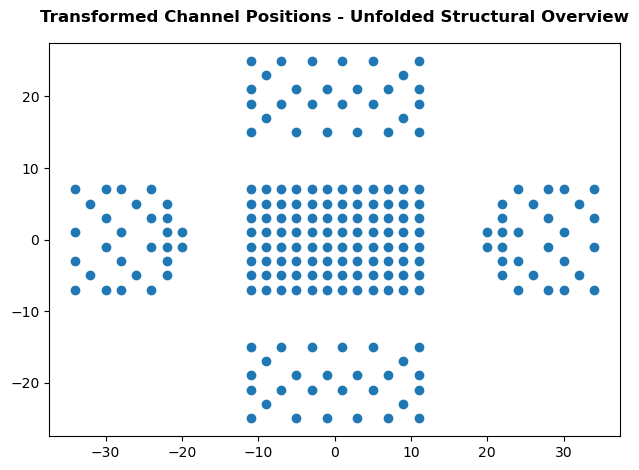

In [78]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.io import loadmat

def generate_unfolded_building_plot(mat_path):
    # =====================================================================
    # 1. LOAD AND PARSE MATLAB MATRIX FILE
    # =====================================================================
    if not os.path.exists(mat_path):
        raise FileNotFoundError(f"Could not locate target file at: {mat_path}")
        
    mat_data = loadmat(mat_path)
    
    # Extract structural location tracker matrix
    raw_loc = mat_data['Location_of_measured_points']
    
    # Convert 4xN matrix to a clean row-by-column Pandas DataFrame
    loc_df = pd.DataFrame(raw_loc.T, columns=['X', 'Y', 'Point_No', 'Face_No'])
    
    # Route matching for the pressure data keys to find the active channel count
    pressure_key = 'Wind_pressure_coefficients' if 'Wind_pressure_coefficients' in mat_data else 'Pressure_coefficients'
    if pressure_key in mat_data:
        total_active_taps = mat_data[pressure_key].shape[1] # Columns = Taps count
        loc_df = loc_df.head(total_active_taps).copy()
        print(f"Successfully sync'd dataset: {total_active_taps} active channels found.")
    else:
        print("⚠️ Warning: No pressure matrix found. Plotting global coordinates list.")


    x = loc_df['X']
    y = loc_df ['Y']

    plt.scatter(x,y)
        
    # 🟢 Create a dictionary of DataFrames for faces 1 through 8
    face_dfs = {face: loc_df[loc_df['Face_No'] == face].reset_index(drop=True) for face in range(1, 9)}


  
    plt.title("Transformed Channel Positions - Unfolded Structural Overview", fontweight='bold', fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

# =====================================================================
# EXECUTION TRIGGER EXAMPLE
# =====================================================================
# Change this path string to point to your local file location to run!
file_target = "C:\WINDLAB_SUMMER\TPU_TEST_FILES\WIND_LOW_RISE_WITH_EAVE\Cp_ts_ROH12_deg000.mat"
generate_unfolded_building_plot(file_target)

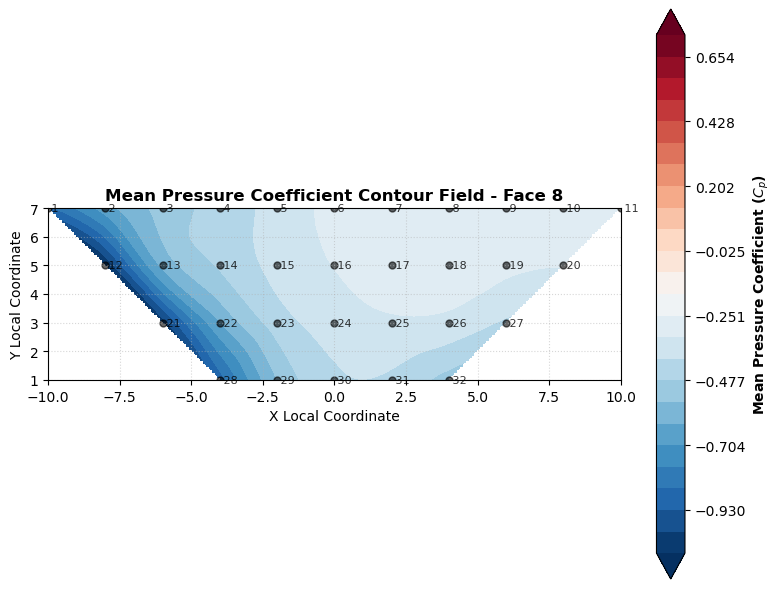

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def plot_single_face_contour(loc_df, pressure_df, face_id):
    """
    Generates a dedicated mean Cp contour plot for one explicitly chosen building face.
    
    Parameters:
    - loc_df: DataFrame containing the raw tap coordinates ('X', 'Y', 'Point_No', 'Face_No')
    - pressure_df: DataFrame containing the time-series wind pressure coefficients
    - face_id: Integer (e.g., 1, 2, 5) targeting the specific face to visualize
    """
    # 1. Calculate the mean pressure coefficient (Cp) for each channel
    mean_cp_series = pressure_df.mean(axis=0)
    mean_cp_df = mean_cp_series.reset_index()
    mean_cp_df.columns = ['Tap no.', 'mean_cp']

    # 2. Map the means back to the coordinates
    total_active_channels = pressure_df.shape[1]
    working_df = loc_df.head(total_active_channels).copy()
    working_df['mean_cp'] = mean_cp_df['mean_cp'].values[:total_active_channels]

    # Get the global min and max Cp across the entire building to keep color scales consistent
    vmin = working_df['mean_cp'].min()
    vmax = working_df['mean_cp'].max()
    levels = np.linspace(vmin, vmax, 25)

    # 3. Isolate the data specifically for the requested face
    face_data = working_df[working_df['Face_No'] == face_id].copy()
    
    if face_data.empty:
        print(f"❌ Error: Face {face_id} was not found in this dataset or contains no active data channels.")
        return

    # Remove any duplicate tap positions within this face zone
    face_data = face_data.drop_duplicates(subset=['X', 'Y'])
    
    # We need at least 3 unique tap coordinates to calculate a 2D surface field mesh
    if len(face_data) < 3:
        print(f"⚠️ Face {face_id} has only {len(face_data)} unique points. Switching to 'nearest' mapping grid fallback.")
        method_choice = 'nearest'
    else:
        method_choice = 'cubic'

    x = face_data['X'].values
    y = face_data['Y'].values
    z = face_data['mean_cp'].values

    # 4. Handle Flat 1D Profiles (e.g., if a wall face only has one straight row of sensors)
    x_min, x_max = x.min(), x.max()
    y_min, y_max = y.min(), y.max()
    
    # Nudge the mesh limits if coordinates are perfectly aligned to prevent QhullError crashes
    if x_min == x_max:
        x_min -= 0.01
        x_max += 0.01
        method_choice = 'nearest'  # Force nearest neighbor if geometrically flat
    if y_min == y_max:
        y_min -= 0.01
        y_max += 0.01
        method_choice = 'nearest'

    # 5. Create a dense coordinate mesh grid for this isolated face
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # 6. Interpolate values locally onto the mesh grid
    try:
        grid_z = griddata((x, y), z, (grid_x, grid_y), method=method_choice)
    except Exception:
        # Emergency absolute backup if triangulation matrices break down
        grid_z = griddata((x, y), z, (grid_x, grid_y), method='nearest')

    # =====================================================================
    # 🎨 RENDER THE TARGET FACE CHART
    # =====================================================================
    plt.figure(figsize=(8, 6))
    
    # Plot the color filled contours
    contour = plt.contourf(grid_x, grid_y, grid_z, levels=levels, cmap='RdBu_r', extend='both')
    
    # Add the colorbar scale (sharing the uniform building bounds)
    cbar = plt.colorbar(contour)
    cbar.set_label('Mean Pressure Coefficient ($C_p$)', fontweight='bold')
    
    # Overlay the exact tap locations as crisp black dots
    plt.scatter(x, y, color='black', s=25, marker='o', alpha=0.6, label='Pressure Taps')
    
    # Add tap labels (Point Number indices)
    for _, row in face_data.iterrows():
        plt.text(row['X'], row['Y'], f" {int(row['Point_No'])}", 
                 color='black', fontsize=8, alpha=0.8, ha='left', va='center')

    # Formatting presentation layers
    plt.title(f"Mean Pressure Coefficient Contour Field - Face {face_id}", fontweight='bold', fontsize=12)
    plt.xlabel("X Local Coordinate", fontsize=10)
    plt.ylabel("Y Local Coordinate", fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.show()

plot_single_face_contour(loc_df, pressure_df, 8)

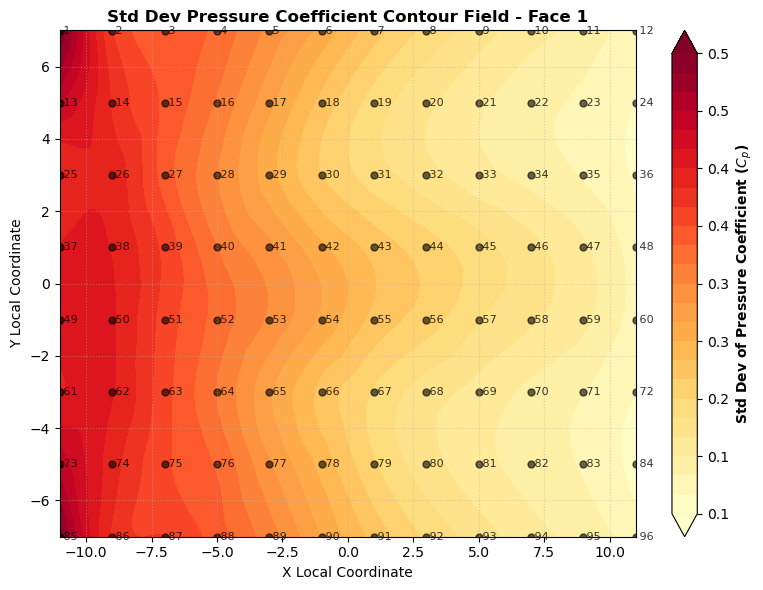

In [98]:
import matplotlib.ticker as ticker
def std_cp_contour(pressure_df, loc_df, face_id):
        """
        Generates a dedicated standard deviation Cp contour plot for one explicitly chosen building face.
        
        Parameters:
        - loc_df: DataFrame containing the raw tap coordinates ('X', 'Y', 'Point_No', 'Face_No')
        - pressure_df: DataFrame containing the time-series wind pressure coefficients
        - face_id: Integer (e.g., 1, 2, 5) targeting the specific face to visualize
        """
        # 1. CHANGE: Calculate the Standard Deviation (std) for each channel instead of the mean
        std_cp_series = pressure_df.std(axis=0)
        std_cp_df = std_cp_series.reset_index()
        std_cp_df.columns = ['Tap no.', 'std_cp']

        # 2. Map the standard deviations back to the coordinates
        total_active_channels = pressure_df.shape[1]
        working_df = loc_df.head(total_active_channels).copy()
        working_df['std_cp'] = std_cp_df['std_cp'].values[:total_active_channels]

        # Get the global min and max Cp across the entire building to keep color scales consistent
        vmin = working_df['std_cp'].min()
        vmax = working_df['std_cp'].max()
        levels = np.linspace(vmin, vmax, 25)

        # 3. Isolate the data specifically for the requested face
        face_data = working_df[working_df['Face_No'] == face_id].copy()
        
        if face_data.empty:
            print(f"❌ Error: Face {face_id} was not found in this dataset or contains no active data channels.")
            return

        # Remove any duplicate tap positions within this face zone
        face_data = face_data.drop_duplicates(subset=['X', 'Y'])
        
        # We need at least 3 unique tap coordinates to calculate a 2D surface field mesh
        if len(face_data) < 3:
            print(f"⚠️ Face {face_id} has only {len(face_data)} unique points. Switching to 'nearest' mapping grid fallback.")
            method_choice = 'nearest'
        else:
            method_choice = 'cubic'

        x = face_data['X'].values
        y = face_data['Y'].values
        z = face_data['std_cp'].values  # CHANGE: Using std values here

        # 4. Handle Flat 1D Profiles (e.g., if a wall face only has one straight row of sensors)
        x_min, x_max = x.min(), x.max()
        y_min, y_max = y.min(), y.max()
        
        # Nudge the mesh limits if coordinates are perfectly aligned to prevent QhullError crashes
        if x_min == x_max:
            x_min -= 0.01
            x_max += 0.01
            method_choice = 'nearest'  # Force nearest neighbor if geometrically flat
        if y_min == y_max:
            y_min -= 0.01
            y_max += 0.01
            method_choice = 'nearest'

        # 5. Create a dense coordinate mesh grid for this isolated face
        grid_x, grid_y = np.meshgrid(
            np.linspace(x_min, x_max, 200),
            np.linspace(y_min, y_max, 200)
        )

        # 6. Interpolate values locally onto the mesh grid
        try:
            grid_z = griddata((x, y), z, (grid_x, grid_y), method=method_choice)
        except Exception:
            # Emergency absolute backup if triangulation matrices break down
            grid_z = griddata((x, y), z, (grid_x, grid_y), method='nearest')

        # =====================================================================
        # 🎨 RENDER THE TARGET FACE CHART
        # =====================================================================
        plt.figure(figsize=(8, 6))
        
        # CHANGE: Switched cmap to 'YlOrRd' because standard deviation is always positive turbulence
        contour = plt.contourf(grid_x, grid_y, grid_z, levels=levels, cmap='YlOrRd', extend='both')
        
        # Add the colorbar scale (sharing the uniform building bounds)
        cbar = plt.colorbar(contour)
        # CHANGE: Label updated to reflect Standard Deviation
        cbar.set_label('Std Dev of Pressure Coefficient ($C_p$)', fontweight='bold')
        cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
        
        # Overlay the exact tap locations as crisp black dots
        plt.scatter(x, y, color='black', s=25, marker='o', alpha=0.6, label='Pressure Taps')
        
        # Add tap labels (Point Number indices)
        for _, row in face_data.iterrows():
            plt.text(row['X'], row['Y'], f" {int(row['Point_No'])}", 
                    color='black', fontsize=8, alpha=0.8, ha='left', va='center')

        # Formatting presentation layers
        # CHANGE: Title updated to reflect Standard Deviation
        plt.title(f"Std Dev Pressure Coefficient Contour Field - Face {face_id}", fontweight='bold', fontsize=12)
        plt.xlabel("X Local Coordinate", fontsize=10)
        plt.ylabel("Y Local Coordinate", fontsize=10)
        plt.grid(True, linestyle=':', alpha=0.5)
        
        # Camera adjustments (Keeps your custom dynamic camera zoom out padding)
        ax = plt.gca()
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()

        pad_x = 0.005  
        pad_y = 0.005

        ax.set_xlim(xmin - pad_x, xmax + pad_x)
        ax.set_ylim(ymin - pad_y, ymax + pad_y)
        
        plt.tight_layout()
        plt.show()



std_cp_contour(pressure_df, loc_df, 1)